## 第16章 下载数据

### 16.1 绘制温度图

- 阿拉斯加州锡特卡温度图

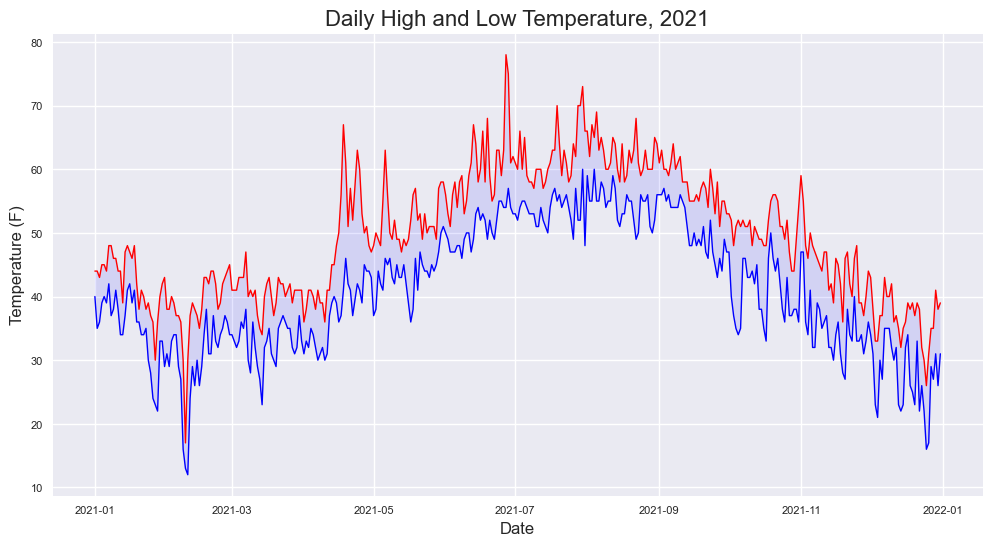

In [8]:
# 屏蔽警告
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import csv
from pathlib import Path
from datetime import datetime

# 读取数据
path = Path("res/sitka.csv")
lines = path.read_text().splitlines()

# 读取标题行
reader = csv.reader(lines)
header = next(reader)

# 读取日期、最高气温、最低气温
dates, highs, lows = [], [], []
for row in reader:
    dates.append(datetime.strptime(row[2], "%Y-%m-%d"))
    highs.append(int(row[4]))
    lows.append(int(row[5]))

# 绘制最高气温、最低气温线图
plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dates, highs, color="red", linewidth=1)  # 最高气温
ax.plot(dates, lows, color="blue", linewidth=1)  # 最低气温
ax.fill_between(dates, highs, lows, facecolor="blue", alpha=0.1)  # 填充区域

# 设置图表样式
ax.set_title("Daily High and Low Temperature, 2021", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Temperature (F)", fontsize=12)
ax.tick_params(labelsize=8)

fig.show()

- 加利福尼亚州死亡谷温度图(处理异常值)

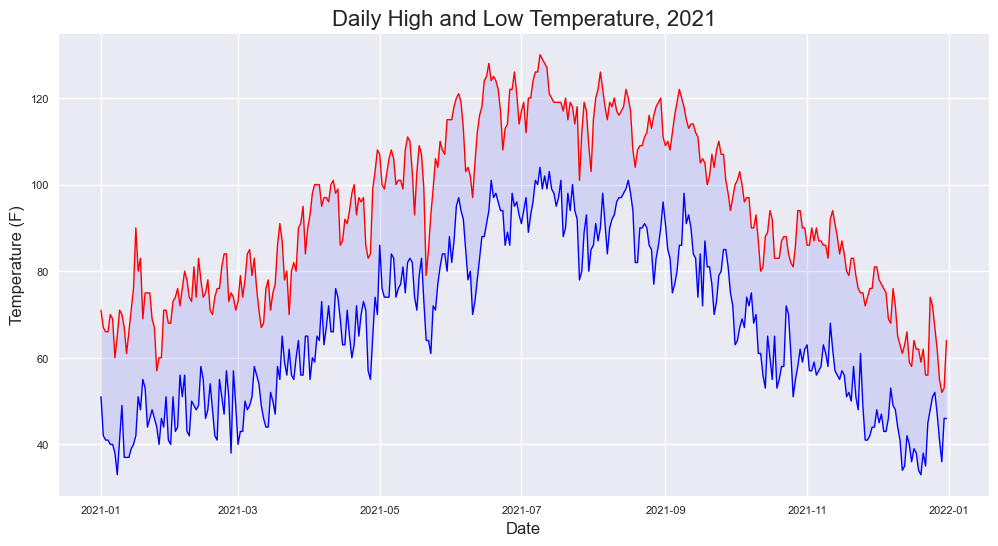

In [9]:
# 屏蔽警告
%matplotlib inline
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import matplotlib.pyplot as plt
import csv
from pathlib import Path
from datetime import datetime

# 读取数据
path = Path("res/valley.csv")
lines = path.read_text().splitlines()

# 读取标题行
reader = csv.reader(lines)
header = next(reader)

# 读取日期、最高气温、最低气温，并处理异常值
dates, highs, lows = [], [], []
for row in reader:
    date = datetime.strptime(row[2], "%Y-%m-%d")
    try:
        high = int(row[3])
        low = int(row[4])
    except ValueError:
        pass
    else:
        dates.append(date)
        highs.append(high)
        lows.append(low)

# 绘制最高气温、最低气温线图
plt.style.use("seaborn-v0_8")
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(dates, highs, color="red", linewidth=1)  # 最高气温
ax.plot(dates, lows, color="blue", linewidth=1)  # 最低气温
ax.fill_between(dates, highs, lows, facecolor="blue", alpha=0.1)  # 填充区域

# 设置图表样式
ax.set_title("Daily High and Low Temperature, 2021", fontsize=16)
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Temperature (F)", fontsize=12)
ax.tick_params(labelsize=8)

fig.show()

### 16.2 绘制地震图

- 绘制全球地震散点图：[res/globaleq.html](res/globaleq.html)

In [ ]:
import json
import pandas as pd
import plotly.express as px # pyright: ignore[reportMissingTypeStubs]
from pathlib import Path

# 读取地震数据
path = Path("res/eqdata.geojson")
try:
    contents = path.read_text()
except:
    contents = path.read_text(encoding='utf-8')
eqs = json.loads(contents)["features"]

# 提取震级、位置、经度、纬度等地震数据
mags, titles, lons, lats = [], [], [], []
for eq in eqs:
    mags.append(eq["properties"]["mag"])
    titles.append(eq["properties"]["title"])
    lons.append(eq["geometry"]["coordinates"][0])
    lats.append(eq["geometry"]["coordinates"][1])

# 绘制全球地震散点图
data = pd.DataFrame(data=zip(lons, lats, titles, mags), columns=['经度', '纬度', '位置', '震级'])
fig = px.scatter(
    data,
    x='经度',
    y='纬度',
    range_x=[-200, 200],
    range_y=[-90, 90],
    size='震级',
    size_max=10,
    color='震级',
    hover_name='位置',
    width=800,
    height=800,
    title='全球地震散点图'
)

# 保存HTML文件并显示
fig.write_html('res/globaleq.html')
fig.show()

---

In [ ]:
# 练习16.9：全球火灾
import csv
import pandas as pd
import plotly.express as px  # pyright: ignore[reportMissingTypeStubs]
from pathlib import Path

path = Path("res/fires.csv")
try:
    lines = path.read_text().splitlines()
except:
    lines = path.read_text(encoding="utf-8").splitlines()
reader = csv.reader(lines)
header = next(reader)

lats, lons, brights = [], [], []
for row in reader:
    try:
        lat = float(row[0])
        lon = float(row[1])
        bright = float(row[2])
    except ValueError:
        pass
    else:
        lats.append(lat)
        lons.append(lon)
        brights.append(bright)

datas = pd.DataFrame(data=zip(lons, lats, brights), columns=["经度", "纬度", "火灾强度"])
fig = px.scatter(
    datas,
    x="经度",
    y="纬度",
    range_x=[-200, 200],
    range_y=[-90, 90],
    color="火灾强度",
    hover_name="火灾强度",
    width=800,
    height=600,
    title="全球火灾散点图"
)
fig.show()